# 220968280 - Anirudh Swaminathan - DSE A2

## week 3 - exercise 1

In [1]:
!pip -V

pip 24.2 from C:\Users\s_ani\Documents\textbooks\5thSem\Deeplearning\venv\Lib\site-packages\pip (python 3.11)



In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.models import Sequential
%matplotlib inline

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 3s 1us/step


In [4]:
batch = 100

### Compute and display the number of classes.

In [5]:
num_classes = max(y_train) + 1
print(f'number of classes: {num_classes}')

number of classes: 10


### Compute and display the dimensions of each image.

In [6]:
num_features = len(X_train[0]) * len(X_train[0][0])
print(f'dimensions of each image: {len(X_train[0])} x {len(X_train[0][0])}')

dimensions of each image: 28 x 28


### Display one image from each class.

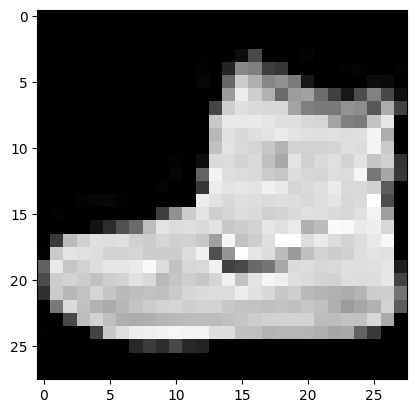

In [7]:
plt.imshow(X_train[0], cmap='gray')

### Perform normalization.

In [8]:
X_train = X_train/255.0
X_test = X_test/255.0

### Performing experiments on Fully Connected Neural Networks (FCNN)

In [9]:
FCNN = Sequential([
    Flatten(input_shape=[28,28]),
    Dense(300, activation='relu'),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])
FCNN.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
FCNN.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['Accuracy'])
h = FCNN.fit(X_train, y_train, epochs=20, batch_size=batch, validation_split=0.15)

Epoch 1/20
510/510 [==============================] - 3s 4ms/step - loss: 0.5164 - Accuracy: 0.8162 - val_loss: 0.4268 - val_Accuracy: 0.8443
Epoch 2/20
510/510 [==============================] - 2s 5ms/step - loss: 0.3699 - Accuracy: 0.8652 - val_loss: 0.3879 - val_Accuracy: 0.8562
Epoch 3/20
510/510 [==============================] - 2s 4ms/step - loss: 0.3327 - Accuracy: 0.8775 - val_loss: 0.3374 - val_Accuracy: 0.8792
Epoch 4/20
510/510 [==============================] - 2s 4ms/step - loss: 0.3052 - Accuracy: 0.8875 - val_loss: 0.3553 - val_Accuracy: 0.8694
Epoch 5/20
510/510 [==============================] - 2s 4ms/step - loss: 0.2896 - Accuracy: 0.8922 - val_loss: 0.3465 - val_Accuracy: 0.8779
Epoch 6/20
510/510 [==============================] - 2s 4ms/step - loss: 0.2783 - Accuracy: 0.8971 - val_loss: 0.3336 - val_Accuracy: 0.8769
Epoch 7/20
510/510 [==============================] - 2s 5ms/step - loss: 0.2618 - Accuracy: 0.9035 - val_loss: 0.3327 - val_Accuracy: 0.8791
Epoch 

In [11]:
FCNN.evaluate(X_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.3624 - Accuracy: 0.8907


[0.36238348484039307, 0.8906999826431274]

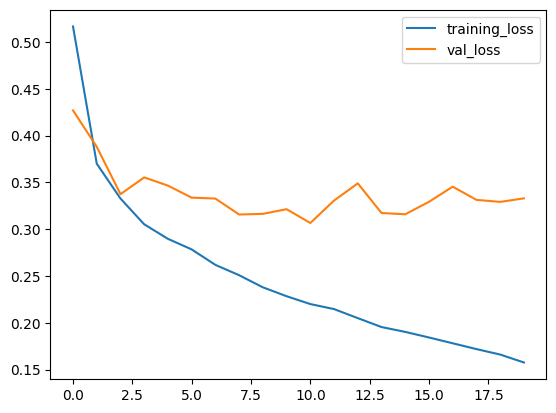

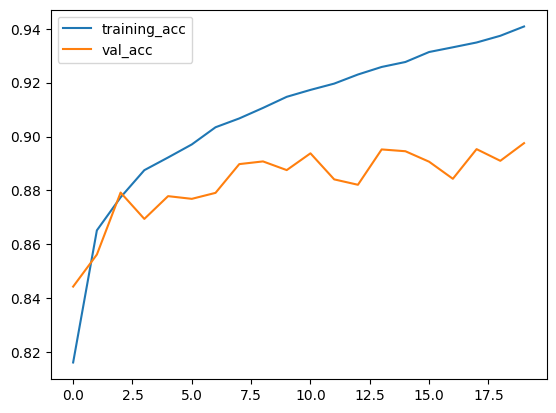

In [12]:
plt.plot(h.history['loss'], label='training_loss')
plt.plot(h.history['val_loss'], label='val_loss')
plt.legend()
plt.show()
plt.plot(h.history['Accuracy'], label='training_acc')
plt.plot(h.history['val_Accuracy'], label='val_acc')
plt.legend()
plt.show()

### Performing experiments on a Convolutional Neural Networks (CNNs):

In [13]:
CNN1 = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(kernel_size=(5, 5), filters=32, strides=1, padding='valid', activation='relu'),
    MaxPool2D(strides=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])
CNN1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 32)        832       
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 32)        0         
 D)                                                              
                                                                 
 flatten_1 (Flatten)         (None, 4608)              0         
                                                                 
 dense_3 (Dense)             (None, 100)               460900    
                                                                 
 dense_4 (Dense)             (None, 10)                1010      
                                                                 
Total params: 462742 (1.77 MB)
Trainable params: 462742 (1.77 MB)
Non-trainable params: 0 (0.00 Byte)
__________________

In [14]:
CNN1.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['Accuracy'])
h = CNN1.fit(X_train, y_train, epochs=12, batch_size=batch, validation_split=0.15)

Epoch 1/12
510/510 [==============================] - 11s 21ms/step - loss: 0.4808 - Accuracy: 0.8325 - val_loss: 0.3627 - val_Accuracy: 0.8724
Epoch 2/12
510/510 [==============================] - 11s 22ms/step - loss: 0.3274 - Accuracy: 0.8838 - val_loss: 0.3132 - val_Accuracy: 0.8902
Epoch 3/12
510/510 [==============================] - 11s 21ms/step - loss: 0.2807 - Accuracy: 0.8990 - val_loss: 0.3183 - val_Accuracy: 0.8872
Epoch 4/12
510/510 [==============================] - 12s 23ms/step - loss: 0.2503 - Accuracy: 0.9097 - val_loss: 0.2857 - val_Accuracy: 0.9002
Epoch 5/12
510/510 [==============================] - 11s 22ms/step - loss: 0.2262 - Accuracy: 0.9191 - val_loss: 0.2655 - val_Accuracy: 0.9069
Epoch 6/12
510/510 [==============================] - 11s 22ms/step - loss: 0.2075 - Accuracy: 0.9235 - val_loss: 0.2668 - val_Accuracy: 0.9044
Epoch 7/12
510/510 [==============================] - 12s 23ms/step - loss: 0.1886 - Accuracy: 0.9322 - val_loss: 0.2563 - val_Accuracy:

In [15]:
CNN1.evaluate(X_test, y_test)

313/313 [==============================] - 1s 4ms/step - loss: 0.2770 - Accuracy: 0.9124


[0.2769899070262909, 0.9124000072479248]

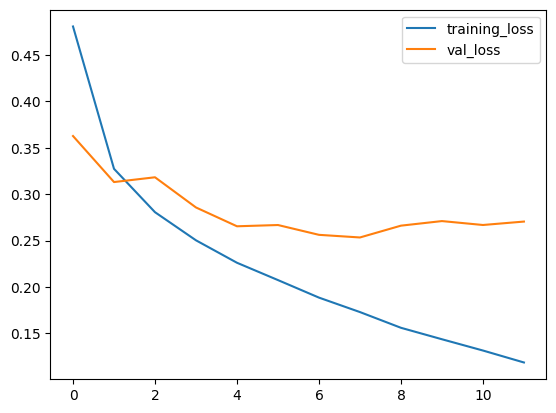

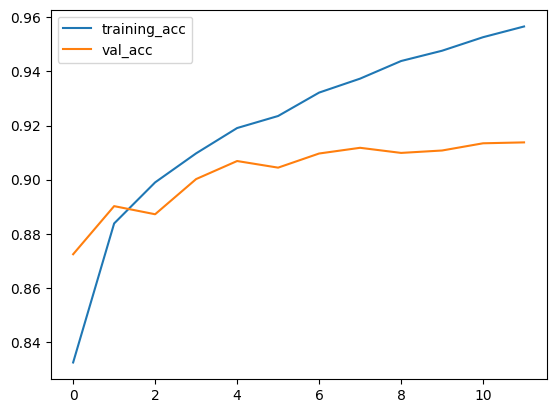

In [17]:
plt.plot(h.history['loss'], label='training_loss')
plt.plot(h.history['val_loss'], label='val_loss')
plt.legend()
plt.show()
plt.plot(h.history['Accuracy'], label='training_acc')
plt.plot(h.history['val_Accuracy'], label='val_acc')
plt.legend()
plt.show()

In [18]:
CNN2 = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(kernel_size=3, filters=32, strides=1, padding='valid', activation='relu'),
    Conv2D(kernel_size=3, filters=32, strides=1, padding='valid', activation='relu'),
    MaxPool2D(strides=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])
CNN2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 conv2d_2 (Conv2D)           (None, 24, 24, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 32)        0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 4608)              0         
                                                                 
 dense_5 (Dense)             (None, 100)               460900    
                                                                 
 dense_6 (Dense)             (None, 10)                1010      
                                                      

In [19]:
CNN2.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['Accuracy'])
h = CNN2.fit(X_train, y_train, epochs=10, batch_size=batch, validation_split=0.15)

Epoch 1/10
510/510 [==============================] - 26s 49ms/step - loss: 0.4532 - Accuracy: 0.8404 - val_loss: 0.3157 - val_Accuracy: 0.8916
Epoch 2/10
510/510 [==============================] - 26s 50ms/step - loss: 0.2816 - Accuracy: 0.8994 - val_loss: 0.2748 - val_Accuracy: 0.9006
Epoch 3/10
510/510 [==============================] - 27s 52ms/step - loss: 0.2320 - Accuracy: 0.9154 - val_loss: 0.2535 - val_Accuracy: 0.9084
Epoch 4/10
510/510 [==============================] - 27s 54ms/step - loss: 0.1976 - Accuracy: 0.9285 - val_loss: 0.2616 - val_Accuracy: 0.9034
Epoch 5/10
510/510 [==============================] - 28s 56ms/step - loss: 0.1683 - Accuracy: 0.9394 - val_loss: 0.2410 - val_Accuracy: 0.9121
Epoch 6/10
510/510 [==============================] - 28s 56ms/step - loss: 0.1429 - Accuracy: 0.9477 - val_loss: 0.2367 - val_Accuracy: 0.9159
Epoch 7/10
510/510 [==============================] - 29s 56ms/step - loss: 0.1214 - Accuracy: 0.9551 - val_loss: 0.2549 - val_Accuracy:

In [20]:
CNN2.evaluate(X_test, y_test)

313/313 [==============================] - 2s 7ms/step - loss: 0.3164 - Accuracy: 0.9137


[0.316371351480484, 0.9136999845504761]

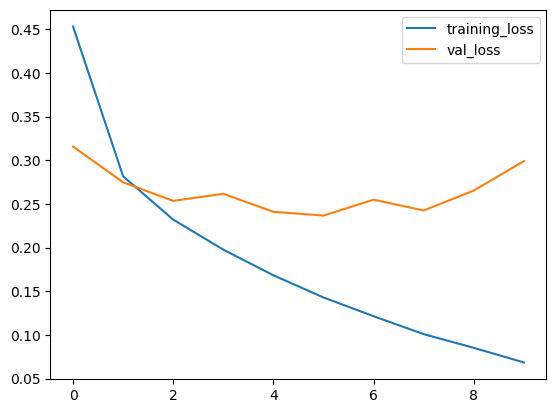

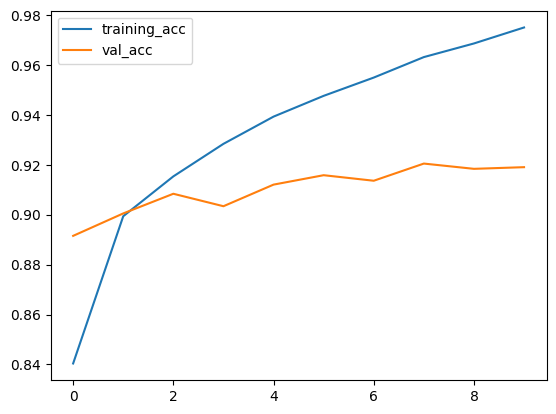

In [21]:
plt.plot(h.history['loss'], label='training_loss')
plt.plot(h.history['val_loss'], label='val_loss')
plt.legend()
plt.show()
plt.plot(h.history['Accuracy'], label='training_acc')
plt.plot(h.history['val_Accuracy'], label='val_acc')
plt.legend()
plt.show()

CNN2 has 0.13% higher accuracy than CNN1.

FCNN has an accuracy of 89.07%. CNN1 has an accuracy of 91.24%. CNN2 has an accuracy of 91.37%. CNN has outperformed FCNN in for this situation.

FCNN - 266610 parameters  
CNN1 - 462742 parameters  
CNN2 - 471478 parameters

Most amount of parameters were added from the initial Dense layer in each of the models.